# Phugoid Motion

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Plugging in the equations to get C and R

In [2]:
def integration_constant (z_t, z, theta):
    if z_t <= 0.0 or z <= 0.0:
        raise  ValueError(f"Error {z_t} or {z} negative")
    C = (np.cos(theta)-(z/(3.0 *z_t)))* np.sqrt(z/z_t)
    return C
    
        

In [3]:
def radius_of_curvature(z_t, z, C):
    if z_t <= 0.0 or z <= 0:
        raise ValueError("Error make z positive")
    denominator = ((1/3)-(C/2)*(z_t/z)**(3/2))
    if denominator == 0.0:
        raise ValueError("denominator zero")
    return z_t/denominator
    


In [4]:
z_t = 64.0
z_0 = 16.0
theta_0_degrees = 0.0
theta_0 = np.deg2rad(theta_0_degrees)

C = integration_constant(z_t, z_0, theta_0)
R = radius_of_curvature(z_t, z_0, C)

print (f"C = {C:.3}")
print (f"R = {R:.3}")

C = 0.458
R = -42.7


In [5]:
assert 0.0 < C < 2.0 / 3.0
np.testing.assert_allclose(C, 11.0 / 24.0, rtol=0.0, atol=1e-12)
np.testing.assert_allclose(R, -128.0 / 3.0, rtol=0.0, atol=1e-12)

Assert checks whether the values are in their specified interval

In [6]:
def rotate_point(x, z, center, angle):
    '''Rotate the point (x, z) about center by angle radians.'''
    x_center, z_center = center
    '''Making center into cooridinates'''
    dx, dz = x - x_center, z - z_center

    x_new = x_center + dx * np.cos(angle) + dz * np.sin(angle)
    z_new = z_center - dx * np.sin(angle) + dz * np.cos(angle)
    return x_new, z_new

**Need to use agent to explain**

trajectory function returns numerical data without deciding how it must be displayed

In [7]:
def trace_phugoid(z_t, z_0, theta_0, n_steps=1000, ds=1.0):
    '''Trace a zero-drag phugoid; theta_0 is supplied in degrees.'''
    if n_steps < 2:
        raise ValueError("n_steps must be at least 2.")

    theta = np.deg2rad(theta_0)
    C = integration_constant(z_t, z_0, theta)

    x_values = [0.0]
    z_values = [z_0]

    for _ in range(n_steps - 1):
        x_current, z_current = x_values[-1], z_values[-1]
        R = radius_of_curvature(z_t, z_current, C)

        if np.isinf(R):
            dtheta = 0.0
            x_new = x_current + ds * np.cos(theta)
            z_new = z_current - ds * np.sin(theta)
        else:
            normal = np.array([-np.sin(theta), -np.cos(theta)])
            center = np.array([x_current, z_current]) + R * normal
            dtheta = ds / R
            x_new, z_new = rotate_point(
                x_current, z_current, center, dtheta
            )

        if z_new <= 0.0:
            break

        x_values.append(x_new)
        z_values.append(z_new)
        theta += dtheta

    return np.asarray(x_values), np.asarray(z_values), C

In [8]:
def plot_flight_path(x, z, C):
    '''Plot a previously computed phugoid trajectory.'''
    fig, ax = plt.subplots(figsize=(9.0, 4.0))
    
    ax.plot(x, -z, linewidth=2.0)
    ax.set_title(f"Flight path for C = {C:.3f}")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$-z$")
    ax.grid()
    ax.set_aspect("equal", adjustable="box")
    return fig, ax

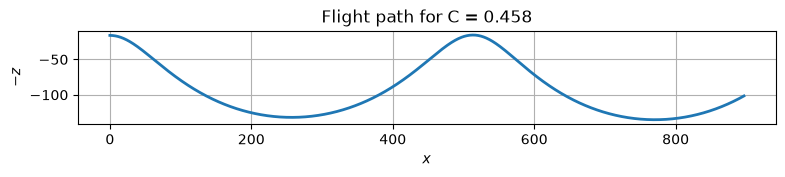

In [9]:
x, z, C = trace_phugoid(z_t=64.0, z_0=16.0, theta_0=0.0)
fig, ax = plot_flight_path(x, z, C)

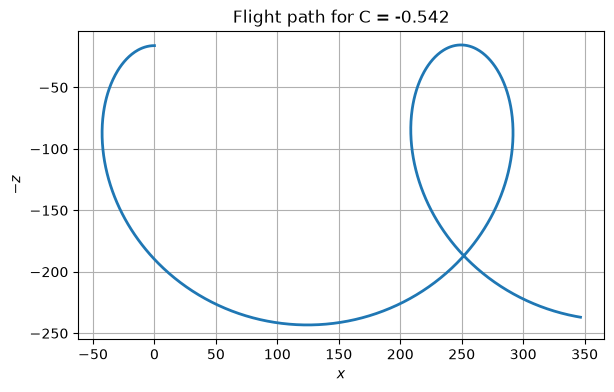

In [10]:
x, z, C = trace_phugoid(z_t=64.0, z_0=16.0, theta_0=180.0)
fig, ax = plot_flight_path(x, z, C)

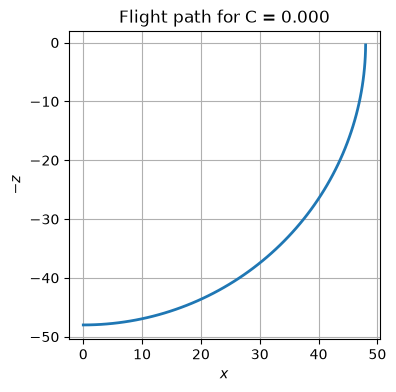

In [11]:
x, z, C = trace_phugoid(z_t=16.0, z_0=48.0, theta_0=0.0)
fig, ax = plot_flight_path(x, z, C)

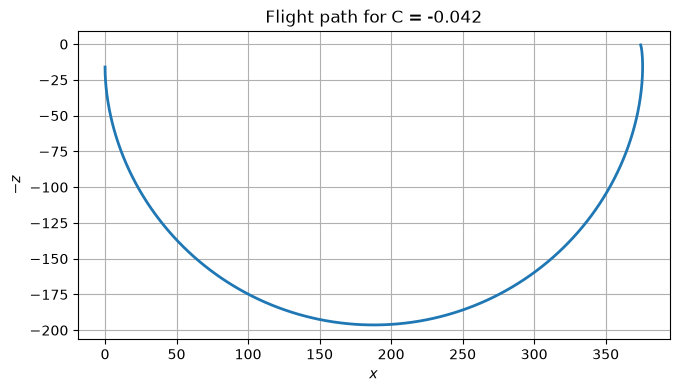

In [12]:
x, z, C = trace_phugoid(z_t=64.0, z_0=16.0, theta_0=-90.0)
fig, ax = plot_flight_path(x, z, C)

In [13]:
z_t_c = 16.0
x_c, z_c, C_c = trace_phugoid(
    z_t=z_t_c,
    z_0=3.0 * z_t_c,
    theta_0=0.0,
    n_steps=50,
    ds=1.0,
)

assert np.isclose(C_c, 0.0)
assert np.allclose(x_c**2 + z_c**2, (3.0 * z_t_c) ** 2)

In [14]:
# assert x_c[1] > x_c[0]
# assert np.isclose(z_c[1], z_c[0])

In [15]:
assert x_c[1] > x_c[0]
assert z_c[1] < z_c[0]

**Agent Review Card**

Review my trace_phugoid() function and its circular-case validation without rewriting the implementation. For 
$C=0$
$C=0$, the path should be a circle of radius 
3
z
t
3z 
t
​
 ; 
z
z is depth measured positive downward. Decide whether the existing checks establish both shape and initial direction. If direction is missing, suggest at most two assertions using only the first two values of x_c and z_c; they must distinguish the intended motion from the same circle traced oppositely. Read the notebook only—do not edit files, execute code or terminal commands, or access the network. Respond in at most 150 words with the explanation and assertions only.